In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import numpy as np

In [23]:
evals_fem = np.loadtxt('../data/semi_torus_evals_fem.txt', usecols=(1,))[:5] # shape: (20,)
evals_fdm = np.load('../data/semi_torus_evals_fdm.npy')[:, :, :5] # shape: (5, 4, 20)


pointwise_rel_err = np.abs(evals_fdm - evals_fem) / np.abs(evals_fem)
l2_rel_err = np.sqrt(np.sum(pointwise_rel_err ** 2, axis=2) / 5)
max_rel_err = np.max(pointwise_rel_err, axis=2)

In [24]:
from utils import *

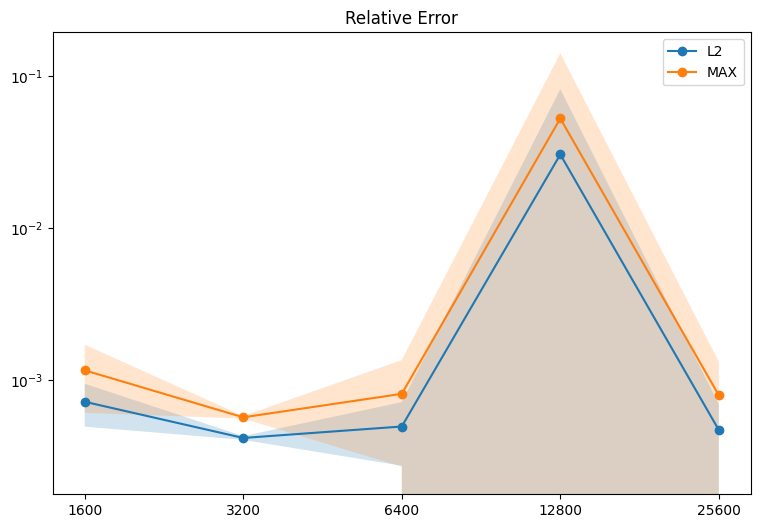

In [25]:
N_vals = [1600, 3200, 6400, 12800, 25600]
l2 = {
    'mean': np.mean(l2_rel_err, axis=1),
    'std': np.std(l2_rel_err, axis=1),
    'plot_kwargs': {
        'label': 'L2'
    }
}

max = {
    'mean': np.mean(max_rel_err, axis=1),
    'std': np.std(max_rel_err, axis=1),
    'plot_kwargs': {
        'label': 'MAX'
    }
}

plot_convergence(N_vals, [l2, max], title='Relative Error')